In [2]:
# analysis
import numpy as np
import pandas as pd 

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# single-cell
import scanpy as sc
import mudata as mu
import liana as li

# import ginsim
import maboss

from pathlib import Path
import os 

# seting global dirg
cwd=Path.cwd()
if cwd.name == "notebooks":
    os.chdir(cwd.parent) 
os.getcwd()

'/home/maxi7524/repositories/project_computational_biology_initial_conditions_pymyboss'

In [3]:
# load model zginml format
maboss_file = Path('data/pymyboss/CellFateModel')
master_model = maboss.load(maboss_file.with_suffix('.bnd')._str, maboss_file.with_suffix('.cfg')._str)
master_model.network

Network([('FASL', <maboss.network.Node at 0x72e2c23dbbc0>),
         ('TNF', <maboss.network.Node at 0x72e2c2967c50>),
         ('TNFR', <maboss.network.Node at 0x72e2c23dbd10>),
         ('DISC_TNF', <maboss.network.Node at 0x72e2c23dbd70>),
         ('DISC_FAS', <maboss.network.Node at 0x72e2c23dbda0>),
         ('FADD', <maboss.network.Node at 0x72e2c23dbdd0>),
         ('RIP1', <maboss.network.Node at 0x72e2c23dbe00>),
         ('RIP1ub', <maboss.network.Node at 0x72e2c23dbe30>),
         ('RIP1K', <maboss.network.Node at 0x72e2c23dbe60>),
         ('IKK', <maboss.network.Node at 0x72e2c23dbe90>),
         ('NFkB', <maboss.network.Node at 0x72e2c23dbec0>),
         ('CASP8', <maboss.network.Node at 0x72e2c23dbef0>),
         ('BAX', <maboss.network.Node at 0x72e2c23dbf20>),
         ('BCL2', <maboss.network.Node at 0x72e2c23dbf50>),
         ('mROS', <maboss.network.Node at 0x72e2c23dbf80>),
         ('ROS', <maboss.network.Node at 0x72e2c23dbfb0>),
         ('ATP', <maboss.network

In [4]:
# here we add value like from liana data
target_receptor = "FASL" # first from list 
communication_score = 0.85

master_model.network.set_istate(target_receptor, [1 - communication_score, communication_score])

In [5]:
# run simulation
results = master_model.run()

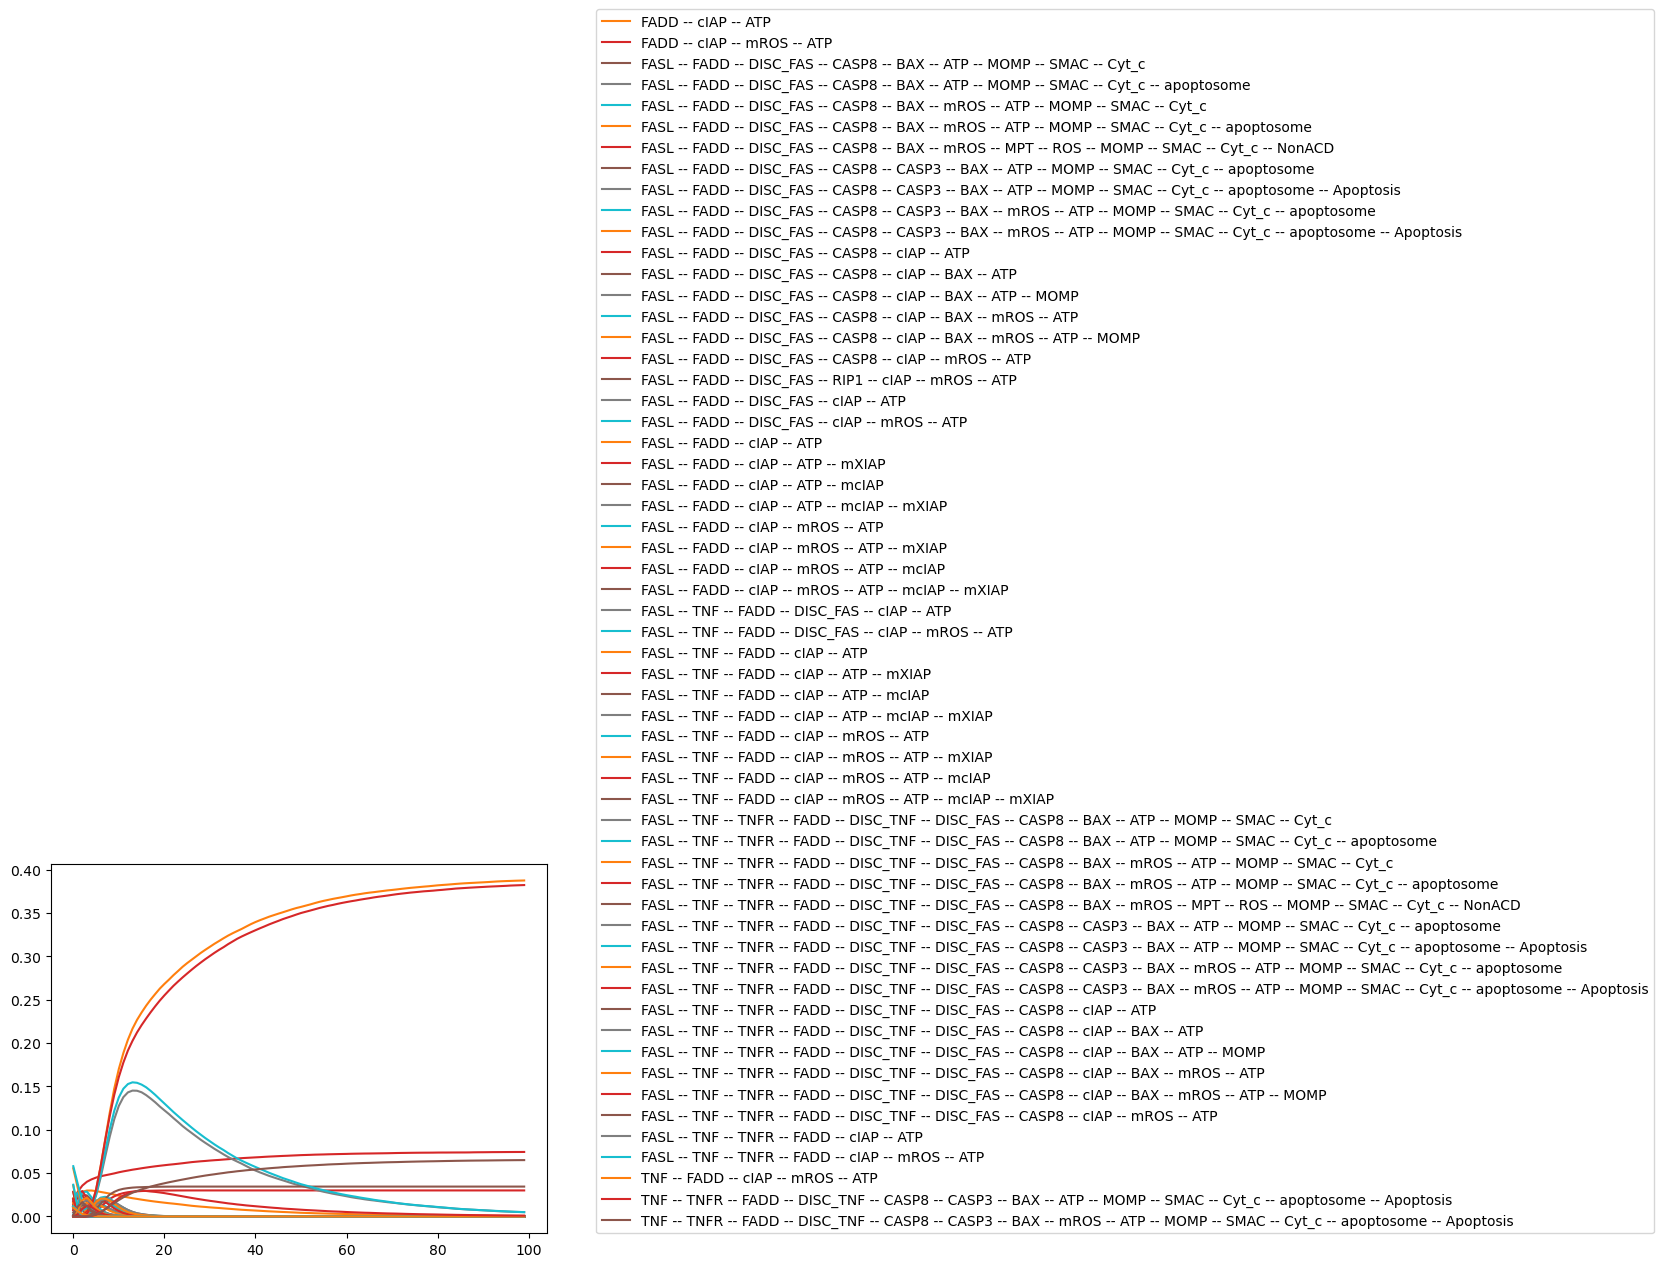

In [10]:
results.plot_trajectory()

In [11]:
import numpy as np

def map_liana_to_maboss(master_model, liana_res, target_cell_type, node_mapping_dict=None, spatial=False):
    """
    Integrates LIANA+ consensus results into a pyMaBoSS model.
    """
    # 1. Filtrowanie dla docelowego typu komórki
    relevant_interactions = liana_res[liana_res['target'] == target_cell_type].copy()
    
    if relevant_interactions.empty:
        print(f"Warning: No interactions found for target {target_cell_type}")
        return master_model

    # 2. Bezpieczne mapowanie nazw węzłów
    model_nodes = list(master_model.network.keys())
    
    # Wybór kolumny wynikowej (zależy jakiej metody agregacji użyto w liana)
    score_col = 'lr_means' if 'lr_means' in relevant_interactions.columns else 'magnitude'
    
    # 3. Normalizacja wyników do przedziału [0.1, 0.9] (unikanie absolutnego zera i jedynki dla stabilności)
    min_val = relevant_interactions[score_col].min()
    max_val = relevant_interactions[score_col].max()
    
    for index, row in relevant_interactions.iterrows():
        liana_receptor = row['receptor'] # lub receptor_complex w zależności od bazy
        
        # Jeżeli mamy słownik mapujący nazwy biologiczne na nazwy węzłów w sieci
        receptor_node = node_mapping_dict.get(liana_receptor, liana_receptor) if node_mapping_dict else liana_receptor
        
        if receptor_node in model_nodes:
            raw_score = row[score_col]
            
            # Bezpieczna normalizacja Min-Max
            if max_val > min_val:
                prob = 0.1 + 0.8 * ((raw_score - min_val) / (max_val - min_val))
            else:
                prob = 0.5
                
            # Logika ON/OFF na podstawie p-value (jeśli interakcja jest wysoce nieistotna lub brak ekspresji)
            # Zakładamy że istnieje kolumna z p-val np. 'cellphone_pvals'
            pval = row.get('cellphone_pvals', 0)
            
            if not spatial:
                if pval > 0.1: # Próg istotności
                    master_model.mutate(receptor_node, "OFF")
                    print(f"Global: Mutated {receptor_node} to OFF (insignificant p-val)")
                else:
                    master_model.network.set_istate(receptor_node, [1 - prob, prob])
                    print(f"Global: Set {receptor_node} istate to [0: {1-prob:.2f}, 1: {prob:.2f}]")
            else:
                # W przypadku PhysiBoSS
                # Zamiast istate, zmieniamy kinetykę (jak szybko receptor reaguje na ligand)
                # Używamy współczynnika (rate)
                base_rate = 1.0 # Domyślna wartość w MaBoSS
                activation_rate = base_rate * prob * 10 # Skalowanie wg potrzeb
                
                master_model.param[f"${receptor_node}_up"] = activation_rate
                print(f"Spatial: Set ${receptor_node}_up rate to {activation_rate:.2f}")

    return master_model

In [ ]:
map_liana_to_maboss(master_model)